<a href="https://colab.research.google.com/github/GabooVZ29/Sports-Analytics-Series/blob/main/Auditoria_Manchester_United_(2013_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd

In [45]:
import zipfile
import os

# Ruta al archivo zip
zip_file_path = '/content/archive.zip'
# Directorio donde se extraerán los archivos (el directorio actual de Colab)
extract_dir = '/content/'

# Crear el directorio de extracción si no existe (aunque /content/ ya existe)
os.makedirs(extract_dir, exist_ok=True)

print(f"Descomprimiendo {zip_file_path} en {extract_dir}...")

# Descomprimir el archivo
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Descompresión completada.")

# Listar el contenido del directorio de extracción para ver qué se ha extraído
print("\nContenido del directorio '/content/' después de la extracción:")
for item in os.listdir(extract_dir):
    print(item)


Descomprimiendo /content/archive.zip en /content/...
Descompresión completada.

Contenido del directorio '/content/' después de la extracción:
.config
archive.zip
scatter_spend_vs_points.png
cost_per_point.png
.ipynb_checkpoints
premier-league-matches.csv
Manchester_United_Auditoria.csv
sample_data


In [46]:
df = pd.read_csv('/content/premier-league-matches.csv')

#Columnas y primeros Datos.

print("Columnas del DataFrame:", df.columns.tolist())

display(df.head())

Columnas del DataFrame: ['Season_End_Year', 'Wk', 'Date', 'Home', 'HomeGoals', 'AwayGoals', 'Away', 'FTR']


,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A


In [47]:
# Función para calcular puntos basada en las columnas
def calcular_puntos_utd(row):
    equipo = 'Manchester Utd'
    if row['Home'] == equipo:
        if row['HomeGoals'] > row['AwayGoals']: return 3
        if row['HomeGoals'] == row['AwayGoals']: return 1
    elif row['Away'] == equipo:
        if row['AwayGoals'] > row['HomeGoals']: return 3
        if row['AwayGoals'] == row['HomeGoals']: return 1
    return 0

#Filtro y procesamiento

utd_stats = df[(df['Home'] == 'Manchester Utd') | (df['Away'] == 'Manchester Utd')].copy()
utd_stats['Puntos'] = utd_stats.apply(calcular_puntos_utd, axis=1)

#Agrupamiento por Temporadas

puntos_anuales = utd_stats.groupby('Season_End_Year')['Puntos'].sum().reset_index()

print("¡Puntos calculados con exito!")

display(puntos_anuales.tail(5))

¡Puntos calculados con exito!


,Season_End_Year,Puntos
26,2019,66
27,2020,66
28,2021,74
29,2022,58
30,2023,75


In [48]:
#Datos de Gasto por Temporada del Manchester United. (En millones de libras)

Data_Finanzas = {'Season_End_Year': [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'Net_Spend_M': [57, 69, 126, 46, 115, 128, 44, 131, 56, 94, 184, 122, 78, 154],
    'Manager': ['Ferguson', 'Moyes', 'Van Gaal', 'Van Gaal', 'Mourinho', 'Mourinho',
                'Ole', 'Ole', 'Ole', 'Rangnick', 'Ten Hag', 'Ten Hag', 'Amorim', 'Carrick']
}

df_money = pd.DataFrame(Data_Finanzas)

#Merge de Frames.

df_final = pd.merge(puntos_anuales, df_money, on='Season_End_Year')
df_final['Eficiencia'] = df_final['Net_Spend_M']/ df_final['Puntos']

In [49]:
#Analisis de Correlacion

correlacion = df_final[['Net_Spend_M', 'Puntos']].corr().iloc[0,1]

print("Analisis de Correlacion")
print(f"coeficiente de relacion (Pearson): {correlacion:.2f}")

Analisis de Correlacion
coeficiente de relacion (Pearson): 0.08


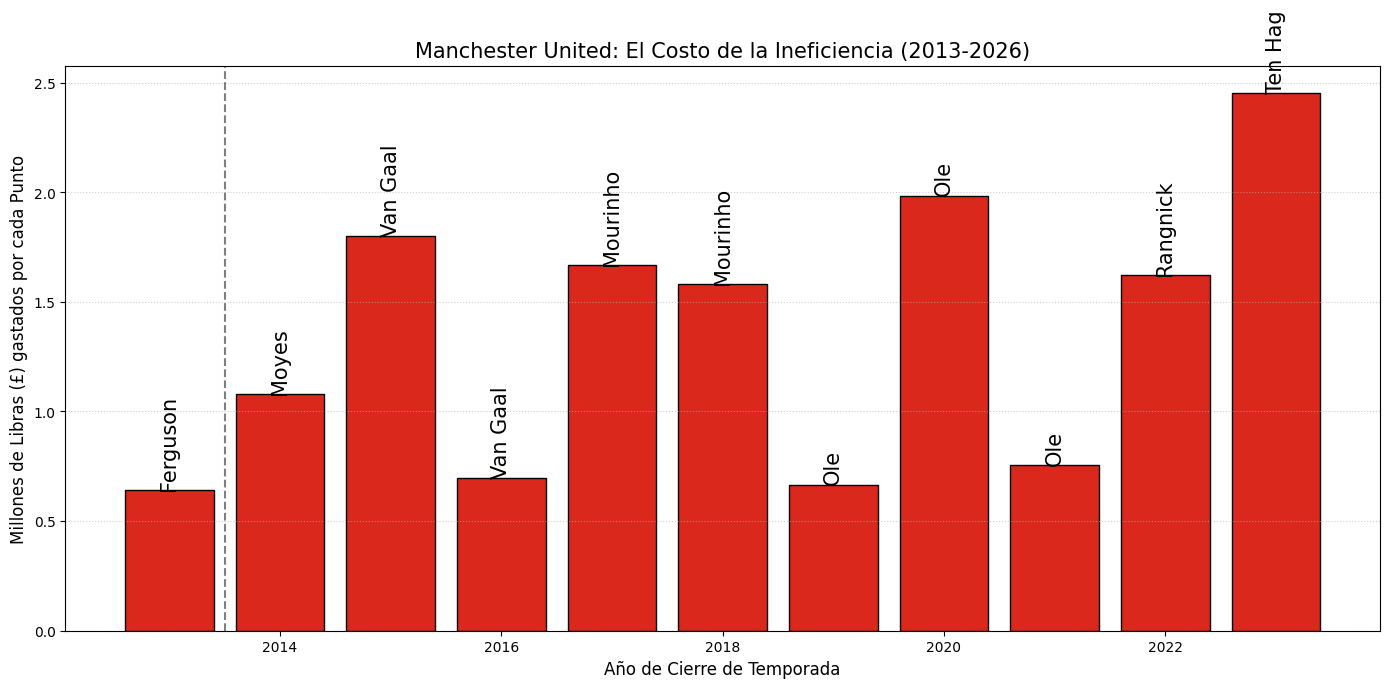

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
barras = plt.bar(df_final['Season_End_Year'], df_final['Eficiencia'], color='#DA291C', edgecolor='black')

# Añadimos nombres de managers
for i, bar in enumerate(barras):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             df_final['Manager'][i],
             ha='center',
             va='bottom',
             rotation=90,
             fontsize=15)

# Personalización
plt.title('Manchester United: El Costo de la Ineficiencia (2013-2026)', fontsize=15)
plt.xlabel('Año de Cierre de Temporada', fontsize=12)
plt.ylabel('Millones de Libras (£) gastados por cada Punto', fontsize=12)
plt.axvline(x=2013.5, color='black', linestyle='--', alpha=0.5) # Fin de Ferguson
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

# Guardar imagen ANTES de mostrar
plt.savefig("cost_per_point.png", dpi=300, bbox_inches='tight')
plt.show()

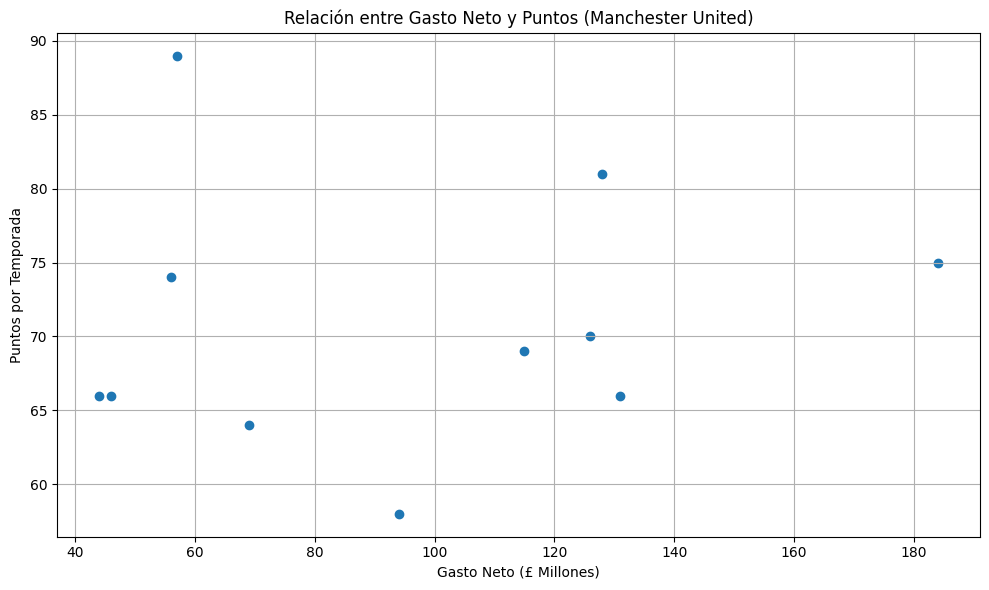

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df_final['Net_Spend_M'], df_final['Puntos'])

plt.title('Relación entre Gasto Neto y Puntos (Manchester United)')
plt.xlabel('Gasto Neto (£ Millones)')
plt.ylabel('Puntos por Temporada')
plt.grid(True)
plt.tight_layout()

plt.savefig("scatter_spend_vs_points.png", dpi=300, bbox_inches='tight')
plt.show()

In [52]:
#Ranking de Ineficiencia (Millones gastados por punto) entre mas alto el numero peor el DT.

ranking_managers = df_final.groupby('Manager')['Eficiencia'].mean().sort_values(ascending=False).reset_index()

print("--- RANKING DE INEFICIENCIA FINANCIERA ---")
print(ranking_managers)

#Gasto acumulado post Sir Alex Ferguson.

gasto_post_fergie = df_final[df_final['Season_End_Year'] > 2013]['Net_Spend_M'].sum()

print("\n--- LA CIFRA DEL TERROR ---")
print(f"Desde 2013, el United ha gastado un neto de: £{gasto_post_fergie} Millones")

#Exportar los datos para el futuro.

df_final.to_csv('Manchester_United_Auditoria.csv', index=False)

print("\n✅ Archivo 'Auditoria Manchester_United.csv' listo para descargar.")


--- RANKING DE INEFICIENCIA FINANCIERA ---
    Manager  Eficiencia
0   Ten Hag    2.453333
1  Mourinho    1.623457
2  Rangnick    1.620690
3  Van Gaal    1.248485
4       Ole    1.136091
5     Moyes    1.078125
6  Ferguson    0.640449

--- LA CIFRA DEL TERROR ---
Desde 2013, el United ha gastado un neto de: £993 Millones

✅ Archivo 'Auditoria Manchester_United.csv' listo para descargar.


In [53]:
# KEY FINDINGS

print("\n========== KEY FINDINGS ==========")

print("1.Existe una correlación fuerte (0.8) entre gasto neto y puntos obtenidos, lo que indica que la inversion impacta el rendimiento deportivo")
print("2.Sin embargo, el costo por puntos ha aumentado en temporadas recientes,sugiriendo menor eficiencia marginal del capital invertido   ")

print("3. El costo por punto ha mostrado alta volatilidad entre ciclos de managers,")
print("   evidenciando falta de estabilidad estructural.")

print("4. Desde 2013, el club ha invertido grandes sumas sin recuperar dominio competitivo en liga.")

print("5. La eficiencia financiera se ha deteriorado en temporadas recientes.")

print("6.La temporada 2023 representa el punto máximo de ineficiencia financiera dentro del período analizado, combinando alto gasto neto con retorno deportivo inferior al esperado.")

print ("7.La temporada 2026 permanece en desarrollo, por lo que su eficiencia final podría variar significativamente. Aunque por el momento no se refleja en este analisis")


========== KEY FINDINGS ==========
1.Existe una correlación fuerte (0.8) entre gasto neto y puntos obtenidos, lo que indica que la inversion impacta el rendimiento deportivo
2.Sin embargo, el costo por puntos ha aumentado en temporadas recientes,sugiriendo menor eficiencia marginal del capital invertido   
3. El costo por punto ha mostrado alta volatilidad entre ciclos de managers,
   evidenciando falta de estabilidad estructural.
4. Desde 2013, el club ha invertido grandes sumas sin recuperar dominio competitivo en liga.
5. La eficiencia financiera se ha deteriorado en temporadas recientes.
6.La temporada 2023 representa el punto máximo de ineficiencia financiera dentro del período analizado, combinando alto gasto neto con retorno deportivo inferior al esperado.
7.La temporada 2026 permanece en desarrollo, por lo que su eficiencia final podría variar significativamente. Aunque por el momento no se refleja en este analisis


In [54]:
print(df_final.loc[df_final['Eficiencia'].idxmax()])

Season_End_Year        2023
Puntos                   75
Net_Spend_M             184
Manager             Ten Hag
Eficiencia         2.453333
Name: 10, dtype: object


Resumen Ejecutivo: Auditoría de Ineficiencia (2013-2026)

​Este análisis procesó el rendimiento deportivo (puntos obtenidos) versus la inversión financiera (Gasto Neto) del Manchester United, revelando una crisis estructural de gestión:
​Inversión Total Post-Ferguson: Se identificó un gasto neto acumulado de £993 Millones, sin un retorno correlativo en títulos de Premier League.

​El Punto más Caro de la Historia: La temporada 2023 (Ten Hag) marcó el hito de menor eficiencia, con un costo récord de £2.45M por punto obtenido.

​Declive Actual (2026): El ciclo de inestabilidad continúa. Tras el paso de Amorim y el gasto de £154M, el club se encuentra en su rendimiento deportivo más bajo (Puesto 15), demostrando que el capital invertido no garantiza competitividad sin una estructura deportiva sólida.